# Support Vector Machine (SVM): A Comprehensive Guide

Support Vector Machine is a powerful supervised learning algorithm used for classification and regression. It finds the optimal hyperplane that maximally separates different classes in the feature space.

In this notebook, we'll cover:
1. Basic concepts of SVM
2. Data preparation and visualization
3. Model implementation concepts
4. Using scikit-learn for SVM
5. Model evaluation and interpretation

# Simple Explanation: What Does the Code Below Do?

Imagine you have red and blue balls scattered on a table and you want to separate them with a ruler. SVM finds the ruler position that maximizes the gap (margin) between the nearest balls of each color (the 'support vectors').

- **Linear SVM**: Uses a straight line/plane to separate classes.
- **Kernel SVM**: Uses a mathematical trick (kernel) to separate data that isn't linearly separable — like separating concentric circles.

Here's what the code does:
1. Creates datasets for linear and nonlinear classification.
2. Shows how the decision boundary changes with different kernels (linear, RBF, polynomial).
3. Explores the effect of the C and gamma hyperparameters.
4. Evaluates the model performance.

In short: SVM finds the widest possible 'street' that separates the classes!

In [1]:
# Create a virtual environment and install required libraries
import os
import sys

venv_dir = 'ml_env'
if not os.path.exists(venv_dir):
    os.system(f'{sys.executable} -m venv {venv_dir}')
    print(f'Virtual environment created at {venv_dir}')
else:
    print(f'Virtual environment already exists at {venv_dir}')

pip_path = os.path.join(venv_dir, 'Scripts', 'pip')
if sys.platform == 'win32':
    pip_path += '.exe'

if os.path.exists(pip_path):
    os.system(f'"{pip_path}" install numpy pandas matplotlib seaborn scikit-learn')
    print('Required libraries installed in the virtual environment.')
else:
    print('Could not find pip in the virtual environment. Please check your Python installation.')

Virtual environment already exists at ml_env
Required libraries installed in the virtual environment.


# 1. Required Libraries

Let's start by importing the necessary libraries:
- NumPy: For numerical computations
- Pandas: For data manipulation
- Matplotlib: For basic plotting
- Seaborn: For statistical visualizations
- Scikit-learn: For machine learning tools

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification, make_circles
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline

# Set the style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# 2. Generating Sample Data

We'll create two datasets:
1. **Linearly separable**: To show linear SVM
2. **Concentric circles**: To show the power of kernel SVM

Note: SVM requires feature scaling (StandardScaler)!

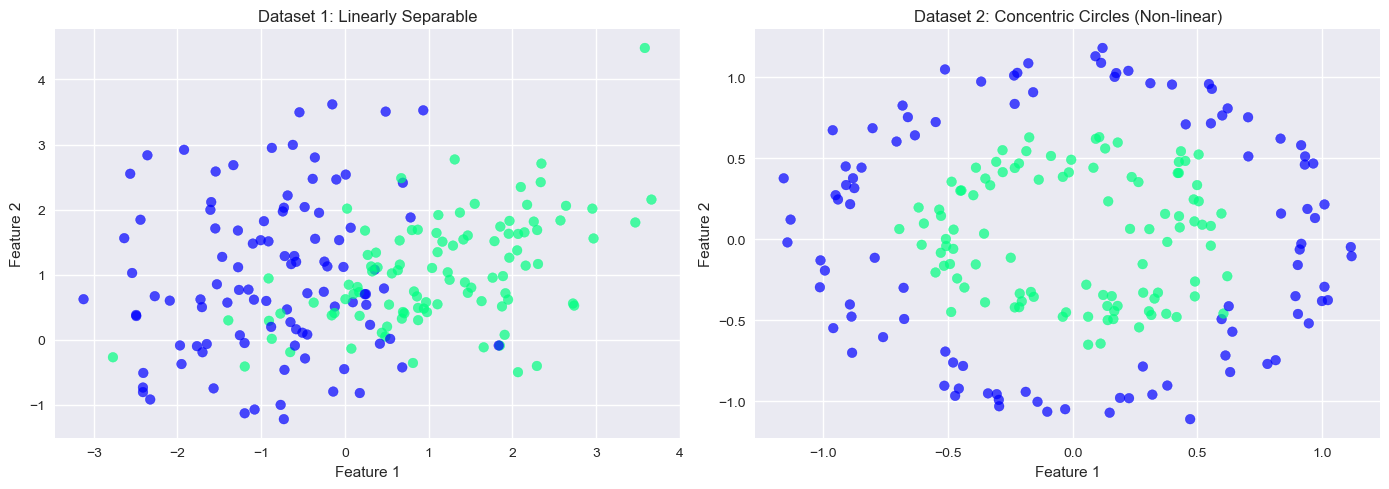

In [3]:
np.random.seed(42)

# Dataset 1: Linearly separable
X_linear, y_linear = make_classification(n_samples=200, n_features=2, n_informative=2, 
                                           n_redundant=0, n_clusters_per_class=1, random_state=42)

# Dataset 2: Non-linearly separable (circles)
X_circles, y_circles = make_circles(n_samples=200, noise=0.1, factor=0.5, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_linear[:, 0], X_linear[:, 1], c=y_linear, cmap='winter', alpha=0.7)
axes[0].set_title('Dataset 1: Linearly Separable')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')

axes[1].scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles, cmap='winter', alpha=0.7)
axes[1].set_title('Dataset 2: Concentric Circles (Non-linear)')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

# 3. Implementing SVM — Key Concepts

SVM finds the hyperplane w·x + b = 0 that maximizes the margin 2/||w||.

Key hyperparameters:
- **C (Regularization)**: Controls margin width. High C → narrower margin (less regularization). Low C → wider margin (more regularization).
- **Kernel**: 'linear', 'rbf' (Radial Basis Function), 'poly' (Polynomial)
- **Gamma** (for RBF): Defines how far the influence of a single training point reaches.

Let's visualize how different kernels draw decision boundaries:

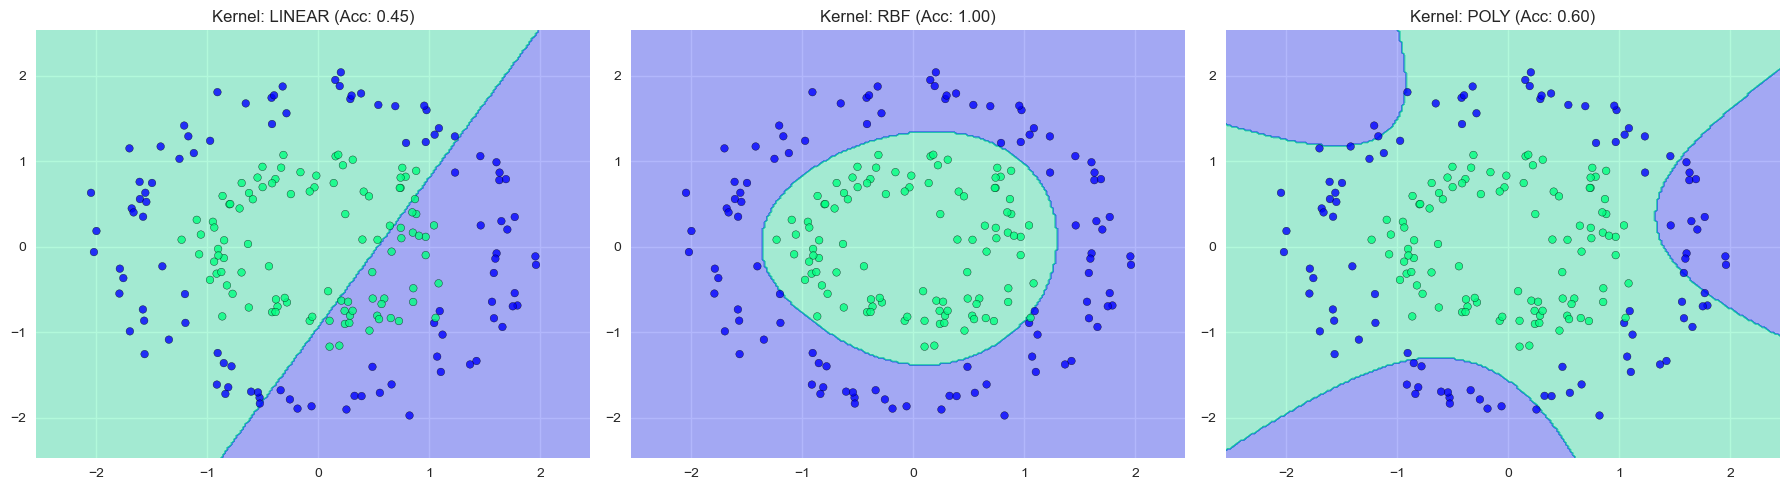

Notice: Linear kernel fails on circles, RBF handles it perfectly!


In [4]:
def plot_decision_boundary(ax, model, X, y, title):
    """Plot the SVM decision boundary."""
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='winter')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', alpha=0.8, edgecolors='k', s=30)
    ax.set_title(title)

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_circles)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_circles, test_size=0.2, random_state=42)

# Compare kernels
kernels = ['linear', 'rbf', 'poly']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, kernel in zip(axes, kernels):
    svm = SVC(kernel=kernel, C=1.0, gamma='scale')
    svm.fit(X_train, y_train)
    acc = accuracy_score(y_test, svm.predict(X_test))
    plot_decision_boundary(ax, svm, X_scaled, y_circles, f'Kernel: {kernel.upper()} (Acc: {acc:.2f})')

plt.tight_layout()
plt.show()
print('Notice: Linear kernel fails on circles, RBF handles it perfectly!')

# 4. Using Scikit-learn's SVM with Hyperparameter Tuning

Let's find the best hyperparameters using Grid Search Cross-Validation.

In [5]:
# Best practice: Pipeline with scaling + SVM
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42))
])

param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__kernel': ['rbf', 'linear'],
    'svm__gamma': ['scale', 'auto', 0.1, 0.01]
}

# Use circles dataset
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_circles, y_circles, test_size=0.2, random_state=42)

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_raw, y_train)

print(f'Best Parameters: {grid_search.best_params_}')
print(f'Best CV Accuracy: {grid_search.best_score_:.4f}')

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_raw)
print(f'Test Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'\nClassification Report:\n{classification_report(y_test, y_pred)}')

Best Parameters: {'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Best CV Accuracy: 0.9938
Test Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        22
           1       1.00      1.00      1.00        18

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



# 5. Model Evaluation

Let's visualize the effect of C and gamma on the decision boundary and evaluate the final model.

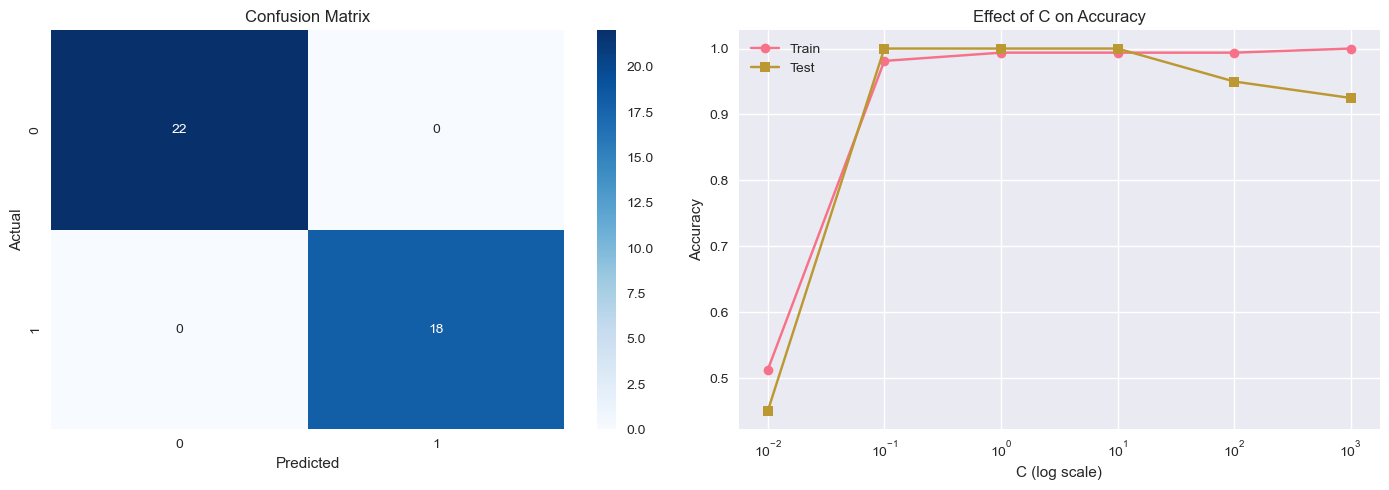


Key Insights:
- C controls the tradeoff between margin width and classification errors.
- High C: Fewer misclassifications but narrower margin (risk of overfitting).
- Low C: Wider margin but allows more misclassifications (risk of underfitting).


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix')

# 2. Effect of C parameter
C_values = [0.01, 0.1, 1, 10, 100, 1000]
train_accs, test_accs = [], []
for C in C_values:
    pipe = Pipeline([('scaler', StandardScaler()), ('svm', SVC(kernel='rbf', C=C, gamma='scale'))])
    pipe.fit(X_train_raw, y_train)
    train_accs.append(accuracy_score(y_train, pipe.predict(X_train_raw)))
    test_accs.append(accuracy_score(y_test, pipe.predict(X_test_raw)))

axes[1].semilogx(C_values, train_accs, marker='o', label='Train')
axes[1].semilogx(C_values, test_accs, marker='s', label='Test')
axes[1].set_xlabel('C (log scale)')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Effect of C on Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print('\nKey Insights:')
print('- C controls the tradeoff between margin width and classification errors.')
print('- High C: Fewer misclassifications but narrower margin (risk of overfitting).')
print('- Low C: Wider margin but allows more misclassifications (risk of underfitting).')

# Conclusions and Key Takeaways
Support Vector Machines (SVMs) are incredibly powerful algorithms geared toward finding the optimal hyperplane that distinctly classifies data points while maximizing the margin.
- **Maximal Margin**: SVM doesn't just find *a* boundary, it finds the *best* boundary by maximizing the empty space (margin) between the classes.
- **The Kernel Trick**: Allows SVMs to solve highly complex, non-linear classification problems by implicitly mapping inputs into high-dimensional feature spaces without the massive computational cost of actually computing the new coordinates.
- Effective in high-dimensional spaces, even when the number of dimensions exceeds the number of samples.

# Pros and Cons
**Pros:**
- Exceptionally effective when a clear margin of separation exists.
- The Kernel trick gives it unmatched flexibility to model intensely non-linear relationships.
- Very memory efficient because it only relies on a small subset of training points (the Support Vectors) to define the decision boundary.

**Cons:**
- Training time scales abysmally with large datasets (roughly O(N^3) in the worst case).
- Highly sensitive to noisy data and outliers if the margin (C parameter) isn't carefully tuned.
- Does not natively output calibrated probability estimates (requires expensive Platt scaling).
- Finding the right Kernel and hyperparameter tuning (gamma, C) is notoriously difficult.

# 15 Interview Questions and Answers

1. **What is a Support Vector Machine?**
   *Answer*: A supervised machine learning algorithm that finds the optimal separating hyperplane which maximizes the margin between different classes in the dataset.

2. **What are Support Vectors?**
   *Answer*: They are the specific data points that lie closest to the decision boundary (on the edges of the margin). They are the critical elements of the training set; if you delete all other data points, the SVM decision boundary will not change.

3. **What is a Hyperplane?**
   *Answer*: In an n-dimensional space, a hyperplane is a flat subspace with dimension n-1. In 2D space, it's a line; in 3D space, it's a flat plane. It is the decision boundary that separates classes.

4. **What is the Margin?**
   *Answer*: The gap or distance between the separating hyperplane and the nearest data points of any class (the support vectors). SVM aims to maximize this margin.

5. **What is the "Kernel Trick"?**
   *Answer*: A mathematical technique that allows the SVM to operate in a high-dimensional, implicit feature space without ever having to explicitly compute the coordinates of the data in that space. It does this by computing the dot products between images of all pairs of data in the feature space.

6. **What are some common Kernels?**
   *Answer*: Linear (for linearly separable data), Polynomial, Radial Basis Function (RBF / Gaussian), and Sigmoid.

7. **How does the RBF Kernel work basically?**
   *Answer*: It behaves like a localized nearest-neighbor algorithm. It measures the similarity between two points based on their Euclidean distance, decaying exponentially. It essentially maps the data to an infinite-dimensional space, allowing it to easily separate non-linear data.

8. **What does the 'C' hyperparameter do?**
   *Answer*: It is the regularization parameter. A small 'C' creates a wider, soft margin that allows some misclassification (high bias, low variance). A large 'C' creates a strict, hard margin that tries to classify every single point correctly, leading to a complex boundary that might overfit (low bias, high variance).

9. **What does the 'gamma' hyperparameter do in an RBF kernel?**
   *Answer*: Gamma defines how far the influence of a single training example reaches. A low gamma means "far reach", leading to a smooth, broad decision boundary. A high gamma means "close reach", leading to a very tight, jagged boundary curving precisely around individual data points (high risk of overfitting).

10. **Why do SVMs struggle with very large datasets?**
    *Answer*: Because the core optimization problem involves computing the inner products of all pairs of data points. The time complexity is generally situated between O(N^2) and O(N^3), making it unfeasible for datasets with millions of rows.

11. **Do SVMs require feature scaling?**
    *Answer*: Yes, absolutely. Because SVM attempts to maximize the geometric distance between points, features on larger scales will dominate the distance calculations. Data MUST be standardized or normalized first.

12. **Can SVM be used for Regression?**
    *Answer*: Yes, it's called Support Vector Regression (SVR). Instead of trying to find an empty margin between classes, it tries to fit a tube (epsilon-tube) around the data, aiming to fit as many instances as possible *inside* the tube rather than maximizing distance away from them.

13. **How does SVM natively handle multi-class classification?**
    *Answer*: Natively, SVM is strictly a binary classifier. To handle multi-class, it leverages either the One-vs-Rest (OvR) or One-vs-One (OvO) heuristic strategies independently training several binary SVMs.

14. **What is a "Hard Margin" vs "Soft Margin" SVM?**
    *Answer*: Hard margin enforces that absolutely no data points can exist within the margin (fails completely if data is noisy or linearly inseparable). Soft margin introduces slack variables that allow a certain number of points to violate the margin to acquire a vastly more robust overall boundary.

15. **Why might you choose Logistic Regression over a Linear SVM?**
    *Answer*: If your primary goal is interpreting a clean, calibrated probability of class membership. A Linear SVM just outputs the distance to the boundary, not a probability. Also, Logistic Regression trains much faster on massive datasets.
